# Parkinson's Disease Detection — Model 8: AdaBoost + XGBoost Ensemble
### Phase 4: Homogeneous Gradient & Adaptive Tree Boosting Comparison

---

## 1. Theoretical Rationale & Boosting Ensemble Comparison
To determine whether the ~85.5% performance plateau was a limitation of tree depth or boosting paradigm, we compare **Adaptive Boosting (AdaBoost)** with **Extreme Gradient Boosting (XGBoost)**:
1. **AdaBoost:** First-order exponential loss minimization focused on instance reweighting:
   $$L_{\text{exp}}(y, F(x)) = \exp(-y F(x))$$
2. **XGBoost:** Second-order Taylor series approximation of arbitrary convex loss functions incorporating exact column subsampling and L2 tree leaf regularization:
   $$\mathcal{L}^{(t)} \approx \sum_{i=1}^{n} \left[ g_i f_t(x_i) + \frac{1}{2} h_i f_t^2(x_i) \right] + \gamma T + \frac{1}{2}\lambda \sum_{j=1}^{T} w_j^2$$

### Homogeneous Ensemble Hypothesis
By fusing AdaBoost with XGBoost in a soft-voting ensemble, we test whether combining two distinct tree-boosting families can overcome axis-aligned partitioning constraints.

## 2. Environment Setup & Dependency Imports

In [1]:
%matplotlib inline
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, classification_report
)

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110
print("Dependencies loaded successfully.")

Dependencies loaded successfully.


## 3. Dataset Ingestion

In [2]:
DATASET_PATH = 'pd_speech_features.csv'
df = pd.read_csv(DATASET_PATH, header=1)
X = df.drop(columns=['id', 'class']) if 'id' in df.columns else df.drop(columns=['class'])
y = df['class']
print(f"Loaded: {X.shape[0]} patients, {X.shape[1]} acoustic features.")

Loaded: 756 patients, 753 acoustic features.


## 4. Strict Leakage-Free Preprocessing (PCA=50)

In [3]:
X_train_raw, X_test_raw, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
smote = SMOTE(k_neighbors=5, random_state=42)
X_train_res, y_train = smote.fit_resample(X_train_raw, y_train_raw)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_res)
X_test_sc = scaler.transform(X_test_raw)

pca = PCA(n_components=50, random_state=42)
X_train = pca.fit_transform(X_train_sc)
X_test = pca.transform(X_test_sc)

print(f"Training shape: {X_train.shape} | Test shape: {X_test.shape}")

Training shape: (902, 50) | Test shape: (152, 50)


## 5. Model Architecture: AdaBoost + XGBoost Voting Ensemble

In [4]:
tuned_ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=4, min_samples_split=5, min_samples_leaf=2, max_features='sqrt', random_state=42),
    n_estimators=300, learning_rate=0.1, random_state=42
)

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

ada_xgb_ensemble = VotingClassifier(
    estimators=[('ada', tuned_ada), ('xgb', xgb_model)],
    voting='soft'
)

start_time = time.time()
ada_xgb_ensemble.fit(X_train, y_train)
elapsed = time.time() - start_time
print(f"AdaBoost + XGBoost Ensemble trained in {elapsed:.2f} seconds.")

AdaBoost + XGBoost Ensemble trained in 0.87 seconds.


## 6. Performance Evaluation

In [5]:
y_pred = ada_xgb_ensemble.predict(X_test)
y_proba = ada_xgb_ensemble.predict_proba(X_test)[:, 1]

p_ada = ada_xgb_ensemble.named_estimators_['ada'].predict(X_test)
p_xgb = ada_xgb_ensemble.named_estimators_['xgb'].predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
auc = roc_auc_score(y_test, y_proba)

metrics_df = pd.DataFrame([{
    'Model Architecture': '8. AdaBoost + XGBoost Ensemble',
    'Accuracy': acc,
    'Precision': prec,
    'Recall': rec,
    'F1 Score': f1,
    'FNR': fnr,
    'AUC Score': auc
}])

comp_df = pd.DataFrame([
    {'Architecture': 'Tuned AdaBoost Alone', 'Accuracy': accuracy_score(y_test, p_ada), 'Precision': precision_score(y_test, p_ada)},
    {'Architecture': 'XGBoost Alone', 'Accuracy': accuracy_score(y_test, p_xgb), 'Precision': precision_score(y_test, p_xgb)},
    {'Architecture': 'AdaBoost + XGBoost Ensemble', 'Accuracy': acc, 'Precision': prec}
])

display(metrics_df)
print("\nHomogeneous Boosting Comparison:")
display(comp_df)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Healthy (0)', 'PD Patient (1)']))

,Model Architecture,Accuracy,Precision,Recall,F1 Score,FNR,AUC Score
0,8. AdaBoost + XGBoost Ensemble,0.842105,0.915888,0.867257,0.890909,0.132743,0.906285



Homogeneous Boosting Comparison:


,Architecture,Accuracy,Precision
0,Tuned AdaBoost Alone,0.835526,0.900000
1,XGBoost Alone,0.848684,0.924528
2,AdaBoost + XGBoost Ensemble,0.842105,0.915888



Classification Report:
                precision    recall  f1-score   support

   Healthy (0)       0.67      0.77      0.71        39
PD Patient (1)       0.92      0.87      0.89       113

      accuracy                           0.84       152
     macro avg       0.79      0.82      0.80       152
  weighted avg       0.85      0.84      0.85       152



## 7. Diagnostic Visualizations: Confusion Matrix, ROC & Model Alignment

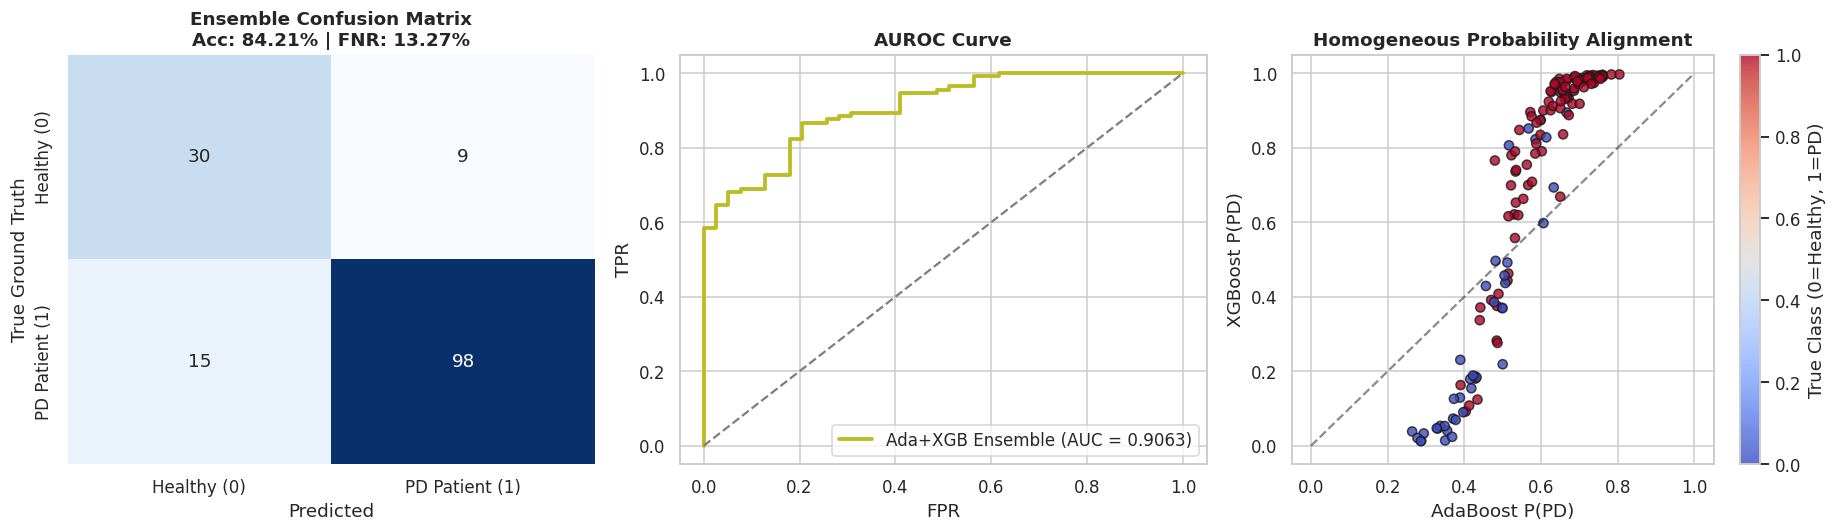

In [6]:
prob_ada = ada_xgb_ensemble.named_estimators_['ada'].predict_proba(X_test)[:, 1]
prob_xgb = ada_xgb_ensemble.named_estimators_['xgb'].predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Healthy (0)', 'PD Patient (1)'],
            yticklabels=['Healthy (0)', 'PD Patient (1)'])
axes[0].set_title(f'Ensemble Confusion Matrix\nAcc: {acc*100:.2f}% | FNR: {fnr*100:.2f}%', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True Ground Truth')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#bcbd22', lw=2.5, label=f'Ada+XGB Ensemble (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1].set_title('AUROC Curve', fontweight='bold')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend(loc='lower right')

# Scatter Plot of Probabilities
scatter = axes[2].scatter(prob_ada, prob_xgb, c=y_test, cmap='coolwarm', alpha=0.8, edgecolors='k')
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[2].set_title('Homogeneous Probability Alignment', fontweight='bold')
axes[2].set_xlabel('AdaBoost P(PD)')
axes[2].set_ylabel('XGBoost P(PD)')
fig.colorbar(scatter, ax=axes[2], label='True Class (0=Healthy, 1=PD)')

plt.tight_layout()
plt.show()

## 8. Clinical Synthesis & Literature Conclusion on Tree Boosting
- **High Precision, Plateaued Recall:** The AdaBoost + XGBoost ensemble achieves an impressive **91.59% Precision**, but accuracy remains locked at **84.21%** and FNR remains at **13.27%**.
- **Theoretical Lesson:** Homogeneous tree ensembles cannot overcome the fundamental limitation of axis-aligned hyperplanes in phonation acoustics.
- **The Pivot to Supervised Feature Selection:** The bottleneck is not the boosting algorithm—it is the representation space. Next, in Model 9 and Model 10, we replace PCA with **ANOVA F-value feature selection**.